In [1]:
import torch
import torch.nn as nn
import gymnasium as gym
import numpy

from torch.distributions.categorical import Categorical

In [2]:
class MultiLayerPerceptron(nn.Module):

    def __init__(
        self, 
        in_features: int, 
        out_features: int, 
        hidden_dim: int,
        n_hidden: int,
    ):
        super().__init__()
        layers = []
        layers.append(
            nn.Linear(
                in_features=in_features,
                out_features=hidden_dim,
                bias=True,
            )
        )
        layers.append(nn.Tanh())
        for i in range(n_hidden):
            layers.append(
                nn.Linear(
                    in_features=hidden_dim,
                    out_features=hidden_dim,
                    bias=True,
                )
            )
            layers.append(nn.Tanh())
        layers.append(
            nn.Linear(
                in_features=hidden_dim,
                out_features=out_features,
                bias=True,
            )
        )
        
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


class VanillaPolicyGradient(nn.Module):

    def __init__(self, obs_dim, actions_dim, n_hidden=3, hidden_dim=64):
        super().__init__()
        self.mlp = MultiLayerPerceptron(
            in_features=obs_dim,
            n_hidden=n_hidden,
            hidden_dim=hidden_dim,
            out_features=actions_dim,
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        logits = self.mlp(obs)
        return logits

In [3]:
class PolicyGradientOptimizer:

    def __init__(self, parameters, alpha):
        self.parameters = list(parameters)
        self.alpha = alpha

    @torch.no_grad
    def print_parameters(self):
        for idx, parameter in enumerate(self.parameters):
            print(f"P({idx})={parameter}, Grad={parameter.grad}")
    
    @torch.no_grad
    def step(self) -> None:
        for idx, parameter in enumerate(self.parameters):
            # Gradient Descent because the loss is negative
            # i.e., minimizing the loss (indirectly) maximizes expected return
            parameter.add_(parameter.grad, alpha=-self.alpha)
        return

    def zero_grad(self) -> None:
        for parameter in self.parameters:
            # if not parameter.grad:
            #     continue
            #parameter.grad.zero_()
            parameter.grad = None
        return

In [4]:
@torch.no_grad
def calculate_rewards_to_go(rewards: list) -> list:
    rewards_size = len(rewards)
    rewards_to_go = rewards_size*[0.0]
    for i in reversed(range(rewards_size)):
        future_rewards = 0.0
        if i+1 < rewards_size:
            future_rewards = rewards_to_go[i+1]
        rewards_to_go[i] = rewards[i] + future_rewards
    return rewards_to_go


def train_step(model, env, optimizer, n_episodes=100):
    rewards = []
    weights = []
    observations = []
    actions = []
    rewards_total = 0
    episodes = 0
    
    done = False
    obs, _ = env.reset()
    # Run trajectories in the environment (N)
    while not done:
        with torch.no_grad():
            observations.append(obs.copy())
            obs_tensor = torch.from_numpy(obs).float()
            logits = model(obs_tensor)
            policy = Categorical(logits=logits)
            action = policy.sample()
            log_prob = policy.log_prob(action)
            
            actions.append(action.item())
            
            obs, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated
            # Store vars
            rewards.append(reward)
            
            # End of a trajectory
            if done:
                done=False
                episodes += 1
                # Calculate Rewards-to-go
                new_rewards = calculate_rewards_to_go(rewards)
                weights += new_rewards
                #weights += [sum(rewards)]*len(rewards)
                rewards_total += new_rewards[0]
                rewards = []
                
                # End of the trajectories sampling
                if episodes >= n_episodes:
                    done = True
                obs, _ = env.reset()
    # Calculate Loss
    observations = torch.tensor(numpy.array(observations), dtype=torch.float32)
    logits = model(observations)
    log_probs = Categorical(logits=logits).log_prob(
        torch.as_tensor(actions, dtype=torch.int64)
    )
    loss = -(log_probs * torch.as_tensor(weights, dtype=torch.float32)).mean()
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # Update / optimize
    optimizer.step()
    return loss.item(), rewards_total


def train_loop(model, env, optimizer, n_episodes=100, n_epochs=100):
    rewards = [] 
    losses = []
    block = int(n_epochs//10)
    for i in range(n_epochs):
        loss, reward = train_step(
            model, 
            env, 
            optimizer,
            n_episodes
        )
        losses.append(loss)
        rewards.append(reward)
        if i % block == 0:
            print(f"Epoch ({i}/{n_epochs}): Reward = {reward}, Loss = {loss}")
    print(f"Epoch ({i}/{n_epochs}): Reward = {reward}, Loss = {loss}")
    env.close()
    return losses, rewards

In [5]:
# optimizer = torch.optim.AdamW(
#     model.parameters(), 
#     lr=0.001, 
#     weight_decay=0.01
# )

In [6]:
env = gym.make("LunarLander-v3")
model = VanillaPolicyGradient(
    obs_dim=env.observation_space.shape[0],
    actions_dim=env.action_space.n,
    n_hidden=2,
    hidden_dim=32,
)

optimizer = PolicyGradientOptimizer(
    parameters=model.parameters(),
    alpha=1e-2
)
# optimizer = torch.optim.AdamW(
#     model.parameters(), 
#     lr=0.01, 
#     weight_decay=0.01
# )

In [7]:
losses, rewards = train_loop(model, env, optimizer, n_episodes=10, n_epochs=10_000)

Epoch (0/10000): Reward = -1850.3247254097826, Loss = -219.7073211669922
Epoch (1000/10000): Reward = -1008.9920510422876, Loss = -92.87483215332031
Epoch (2000/10000): Reward = 1236.049281485736, Loss = 38.372825622558594
Epoch (3000/10000): Reward = -7770.568947355081, Loss = -0.009083450771868229
Epoch (4000/10000): Reward = -8358.935725011343, Loss = -0.017259743064641953
Epoch (5000/10000): Reward = -9919.307833515828, Loss = -0.0032325214706361294
Epoch (6000/10000): Reward = -9171.936093053317, Loss = -0.006845373194664717
Epoch (7000/10000): Reward = -8238.355082883729, Loss = -0.001910009072162211
Epoch (8000/10000): Reward = -6018.788245480155, Loss = -0.000832672871183604
Epoch (9000/10000): Reward = -8896.518642423101, Loss = -0.0006409171619452536
Epoch (9999/10000): Reward = -14375.35227019868, Loss = -0.0001773112453520298


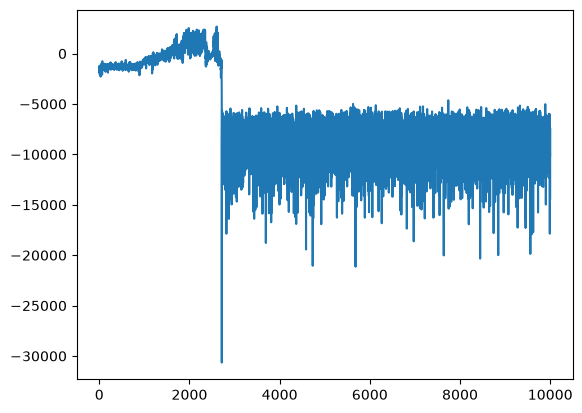

In [8]:
import matplotlib.pyplot as plt

plt.plot(rewards)

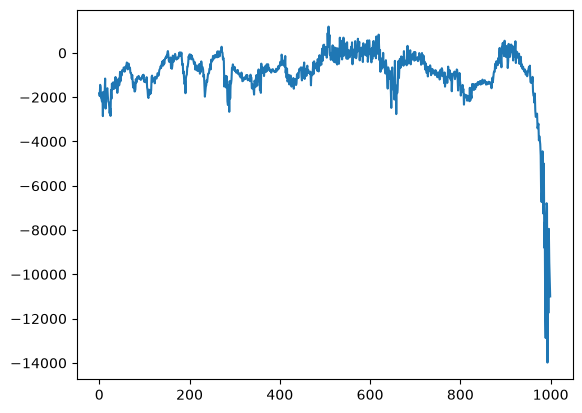

In [250]:
import matplotlib.pyplot as plt

plt.plot(rewards)

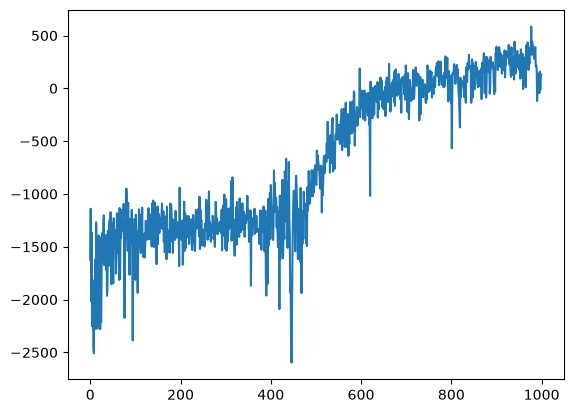

In [232]:
import matplotlib.pyplot as plt

plt.plot(rewards)

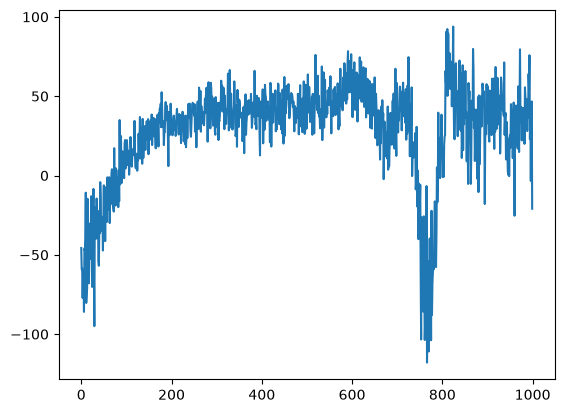

In [206]:
import matplotlib.pyplot as plt

plt.plot(rewards)

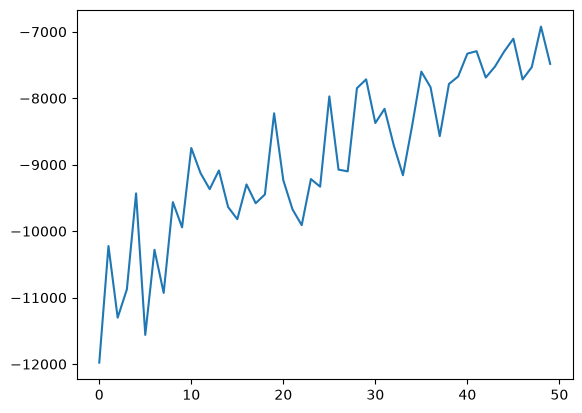

In [197]:
import matplotlib.pyplot as plt

plt.plot(rewards)

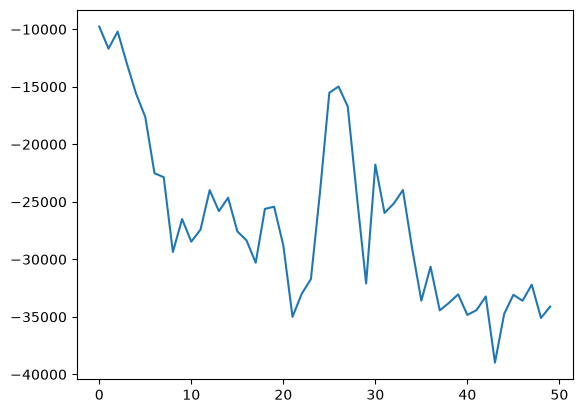

In [192]:
import matplotlib.pyplot as plt

plt.plot(rewards)

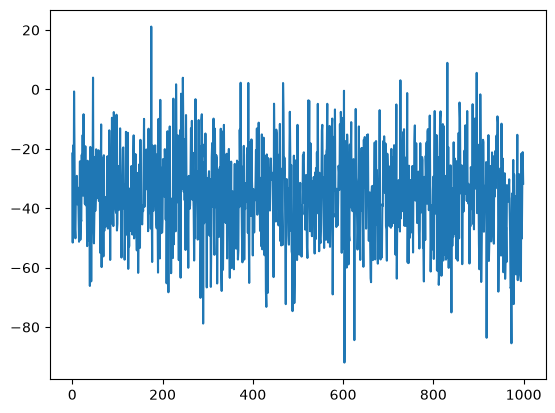

In [162]:
import matplotlib.pyplot as plt

plt.plot(rewards)

In [10]:
def play(model, env, n_rounds, random=True):
    obs, _ = env.reset()
    done = False
    rounds = 0
    while not done:
        if not random:
            logits = model(obs)
            action = Categorical(logits=logits).sample().item()
        else:
            action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            done = False
            rounds += 1
            if rounds > n_rounds:
                done = True
            obs, _ = env.reset()
    env.close()

In [11]:
env = gym.make("LunarLander-v3", render_mode='human')
play(model, env, n_rounds=10)

In [ ]:
env = gym.make("LunarLander-v3", render_mode='human')
play(model, env, n_rounds=10, random=True)